# 01 — Data Preprocessing

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()

if not (REPO_ROOT / "utils").exists():
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.config import DATASETS, ROOT
from utils.preprocessing import (
    load_raw_dataset,
    preprocess_and_split,
    save_processed_data,
)


DATASET: breast
Raw shape: (569, 30)
Class counts:
diagnosis
0    357
1    212
Name: count, dtype: int64
Missing values: 0


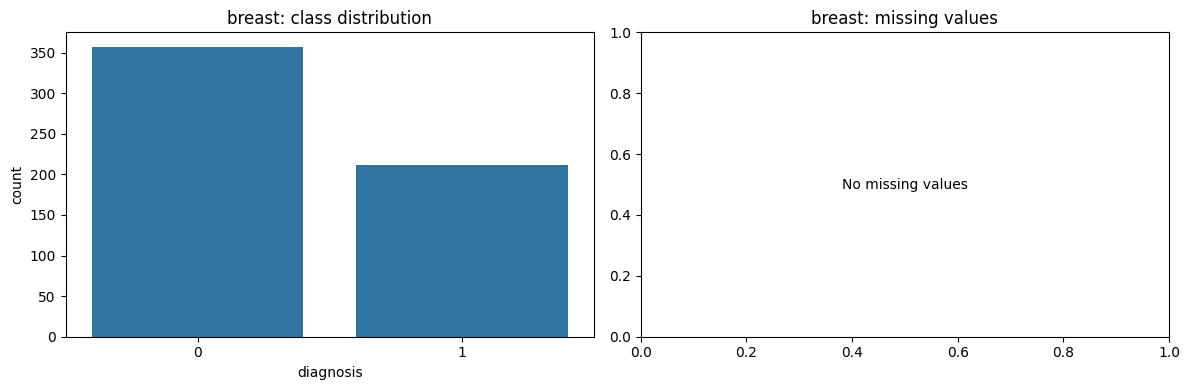

Train: (341, 30)
Validation: (114, 30)
Test: (114, 30)
Processed features: 30


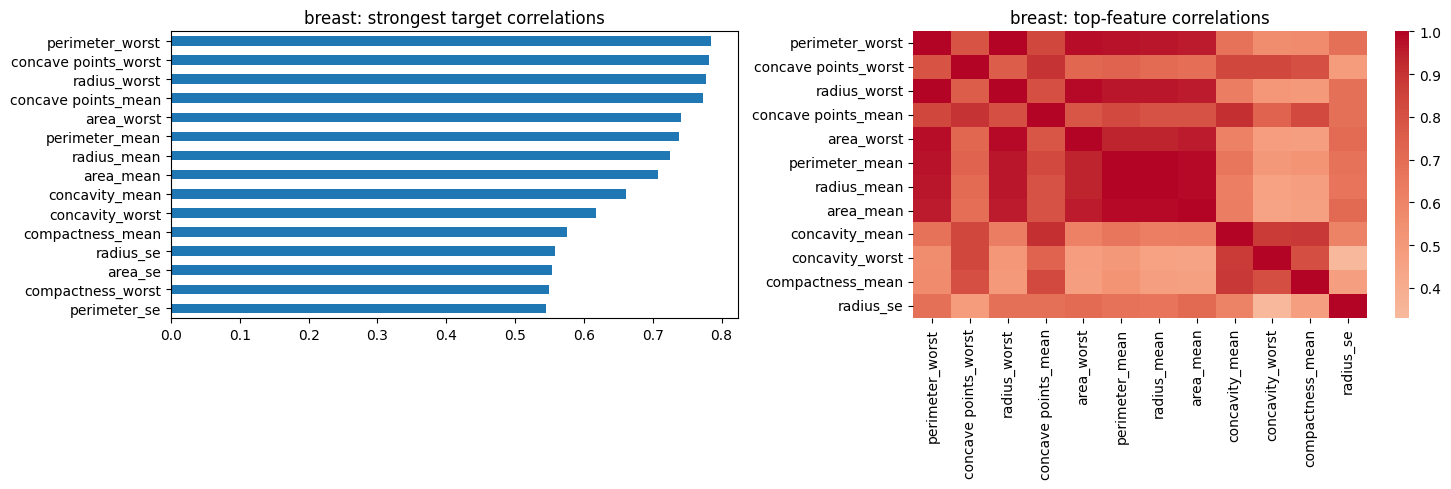


DATASET: heart
Raw shape: (920, 13)
Class counts:
num
1    509
0    411
Name: count, dtype: int64
Missing values: 1759


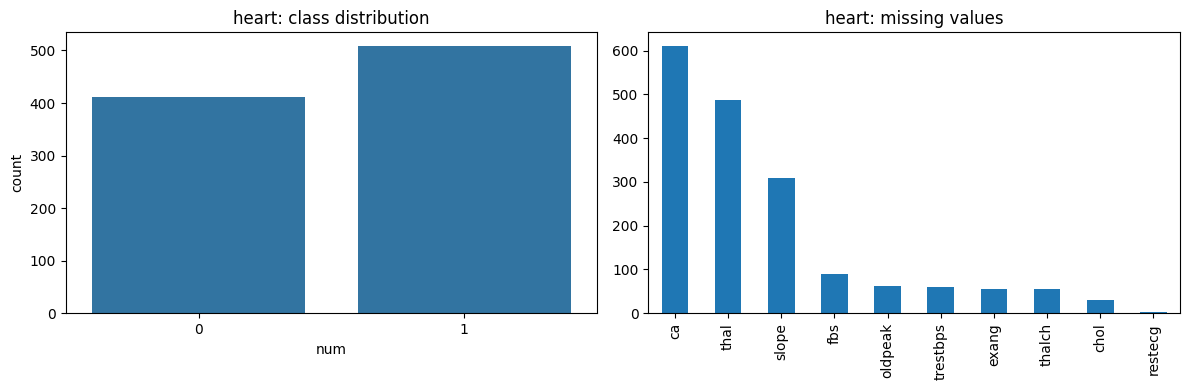

Train: (552, 25)
Validation: (184, 25)
Test: (184, 25)
Processed features: 25


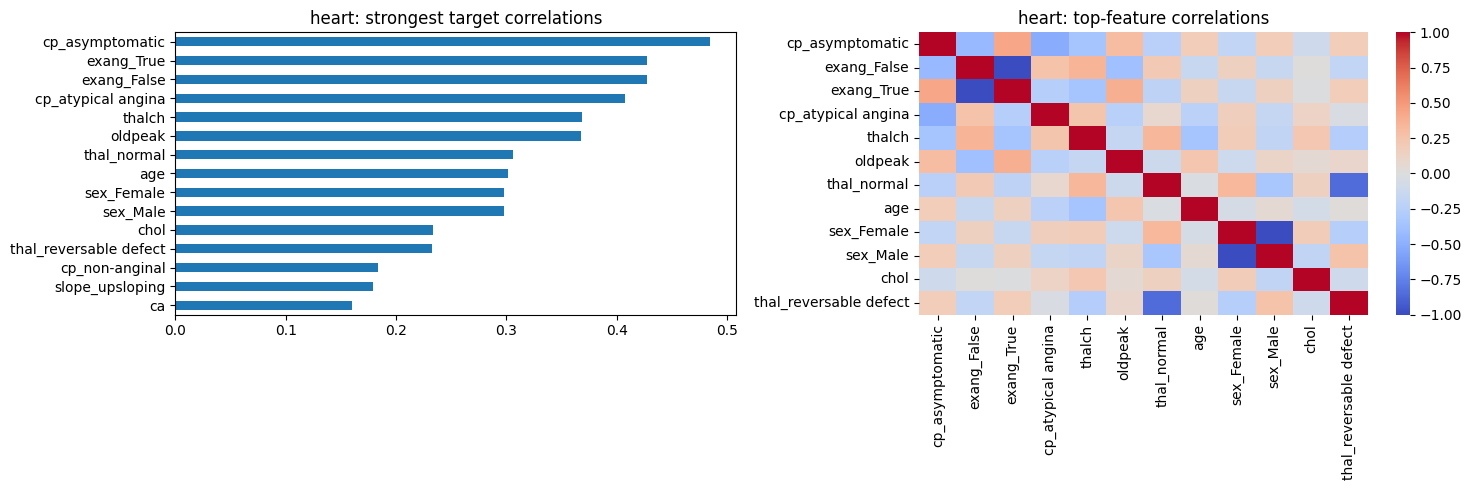

In [2]:
eda_dir = ROOT / "results" / "eda"
eda_dir.mkdir(parents=True, exist_ok=True)

for dataset_name in DATASETS:
    print("\n", "=" * 60)
    print("DATASET:", dataset_name)
    print("=" * 60)

    X_raw, y_raw = load_raw_dataset(dataset_name)

    print("Raw shape:", X_raw.shape)
    print("Class counts:")
    print(y_raw.value_counts())
    print("Missing values:", X_raw.isna().sum().sum())

    missing = X_raw.isna().sum()
    missing = missing[missing > 0].sort_values(
        ascending=False
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.countplot(x=y_raw, ax=axes[0])
    axes[0].set_title(
        f"{dataset_name}: class distribution"
    )

    if len(missing):
        missing.plot.bar(ax=axes[1])
        axes[1].set_title(
            f"{dataset_name}: missing values"
        )
    else:
        axes[1].text(
            0.5,
            0.5,
            "No missing values",
            ha="center",
            va="center",
        )
        axes[1].set_title(
            f"{dataset_name}: missing values"
        )

    plt.tight_layout()
    plt.savefig(
        eda_dir / f"{dataset_name}_data_quality.png",
        dpi=150,
    )
    plt.show()

    arrays = preprocess_and_split(dataset_name)
    save_processed_data(dataset_name, arrays)

    (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test,
        feature_names,
    ) = arrays

    print("Train:", X_train.shape)
    print("Validation:", X_val.shape)
    print("Test:", X_test.shape)
    print("Processed features:", len(feature_names))

    # Correlations use training data only.
    train_df = pd.DataFrame(
        X_train,
        columns=feature_names,
    )

    target_series = pd.Series(
        y_train,
        index=train_df.index,
    )

    correlations = (
        train_df.corrwith(target_series)
        .abs()
        .sort_values(ascending=False)
    )

    top_features = correlations.head(12).index

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    correlations.head(15).sort_values().plot.barh(
        ax=axes[0]
    )
    axes[0].set_title(
        f"{dataset_name}: strongest target correlations"
    )

    sns.heatmap(
        train_df[top_features].corr(),
        cmap="coolwarm",
        center=0,
        ax=axes[1],
    )
    axes[1].set_title(
        f"{dataset_name}: top-feature correlations"
    )

    plt.tight_layout()
    plt.savefig(
        eda_dir / f"{dataset_name}_correlations.png",
        dpi=150,
    )
    plt.show()